In [10]:
import pandas as pd
import numpy as np

from google.colab import files
upload = files.upload()

Saving Ecommerce_Sales_Data_2024_2025.csv to Ecommerce_Sales_Data_2024_2025.csv


In [12]:
df = pd.read_csv("Ecommerce_Sales_Data_2024_2025.csv")
df.head()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,19-10-2024,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5.0,68958.6,10525.09,Debit Card
1,10002,19-10-2024,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,0.0,33732.0,6299.66,Debit Card
2,10003,04-11-2023,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20.0,207603.2,19850.27,Credit Card
3,10004,23-05-2025,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,5.0,158610.0,36311.02,UPI
4,10005,19-01-2025,Akarsh Kaul,West,Goa,Clothing,Kids Wear,Kids Wear Quo,1,50037,10.0,45033.3,9050.04,Debit Card


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       5000 non-null   int64  
 1   Order Date     5000 non-null   object 
 2   Customer Name  5000 non-null   object 
 3   Region         5000 non-null   object 
 4   City           5000 non-null   object 
 5   Category       5000 non-null   object 
 6   Sub-Category   5000 non-null   object 
 7   Product Name   5000 non-null   object 
 8   Quantity       5000 non-null   int64  
 9   Unit Price     5000 non-null   int64  
 10  Discount       4999 non-null   float64
 11  Sales          5000 non-null   float64
 12  Profit         5000 non-null   float64
 13  Payment Mode   5000 non-null   object 
dtypes: float64(3), int64(3), object(8)
memory usage: 547.0+ KB


In [14]:
df.describe()

,Order ID,Quantity,Unit Price,Discount,Sales,Profit
count,5000.000000,5000.000000,5000.000000,4999.000000,5000.000000,5000.000000
mean,12500.500000,2.992600,39760.904600,10.040608,106733.204870,15941.746982
std,1443.520003,1.413133,22831.783946,7.084365,85108.208202,14897.684916
min,10001.000000,1.000000,222.000000,0.000000,264.100000,19.120000
25%,11250.750000,2.000000,20312.250000,5.000000,39766.537500,4892.295000
50%,12500.500000,3.000000,39459.500000,10.000000,83080.325000,11108.525000
75%,13750.250000,4.000000,59721.750000,15.000000,156968.587500,22467.987500
max,15000.000000,5.000000,79998.000000,20.000000,398485.000000,89688.440000


In [15]:
df.isnull().any()

,0
Order ID,False
Order Date,False
Customer Name,False
Region,False
City,False
Category,False
Sub-Category,False
Product Name,False
Quantity,False
Unit Price,False


In [17]:
df['Discount'] = df['Discount'].fillna(df['Discount'].mean())

In [21]:
df.isnull().sum()

,0
Order ID,0
Order Date,0
Customer Name,0
Region,0
City,0
Category,0
Sub-Category,0
Product Name,0
Quantity,0
Unit Price,0


In [20]:
df.duplicated().sum()

np.int64(0)

In [22]:
df['Order Date'] = pd.to_datetime(df["Order Date"])

/tmp/ipykernel_31102/1134126591.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Order Date'] = pd.to_datetime(df["Order Date"])


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       5000 non-null   int64         
 1   Order Date     5000 non-null   datetime64[ns]
 2   Customer Name  5000 non-null   object        
 3   Region         5000 non-null   object        
 4   City           5000 non-null   object        
 5   Category       5000 non-null   object        
 6   Sub-Category   5000 non-null   object        
 7   Product Name   5000 non-null   object        
 8   Quantity       5000 non-null   int64         
 9   Unit Price     5000 non-null   int64         
 10  Discount       5000 non-null   float64       
 11  Sales          5000 non-null   float64       
 12  Profit         5000 non-null   float64       
 13  Payment Mode   5000 non-null   object        
dtypes: datetime64[ns](1), float64(3), int64(3), object(7)
memory usage: 547.

In [24]:
# Total Sales
df["Sales"].sum()

np.float64(533666024.35)

In [25]:
# Total Profit
df["Profit"].sum()

np.float64(79708734.91)

In [27]:
# Sales by Category
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

,Sales
Category,
Home Decor,57233222.35
Furniture,56647187.90
Clothing,55053908.30
Books,54932643.00
Kitchen,54227902.30
Electronics,52587883.95
Toys,52227366.45
Sports,52069397.25
Beauty,50803409.70


In [29]:
# Sales by Sub-Category

df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending= False)

,Sales
Sub-Category,
Sofa,15185544.25
Lamp,14767580.20
Tennis Racket,12934015.25
Women's Wear,12646602.90
Fiction,12376112.80
Non-Fiction,12219033.75
Bed,12211588.60
Juicer,12194033.75
Headphones,12058508.60


In [32]:
# Top 10 Products

df.groupby('Product Name')['Sales'].sum().sort_values(ascending= False).head(10)

,Sales
Product Name,
Headphones Accusantium,857184.20
Spices Quibusdam,687651.25
Accessories Repellendus,687083.30
Bed Tenetur,670994.80
Laptop Similique,666640.60
Lamp Enim,665920.20
Shampoo Commodi,659546.60
Lamp Veritatis,652909.50
Men's Wear Voluptatibus,649048.00


In [34]:
# Region-wise sales

df.groupby('Region')["Sales"].sum()

,Sales
Region,
East,1.358116e+08
North,1.435782e+08
South,1.232302e+08
West,1.310460e+08


In [36]:
# City-wise sales

df.groupby('City')["Sales"].sum().sort_values(ascending= False)

,Sales
City,
Bangalore,29989840.85
Lucknow,29901483.40
Guwahati,29606888.90
Chandigarh,29331057.35
Jaipur,29319402.90
Amritsar,28746184.20
Surat,28532934.65
Patna,27702815.20
Bhubaneswar,27088786.45


In [37]:
# Payment Mode analysis
df["Payment Mode"].value_counts()

,count
Payment Mode,
Net Banking,1010
COD,1005
Debit Card,1003
Credit Card,994
UPI,988


In [39]:
# Time-Based Analysis
# Extract Month

df['Month'] = df["Order Date"].dt.month
df.head()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode,Month
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5.0,68958.6,10525.09,Debit Card,10
1,10002,2024-10-19,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,0.0,33732.0,6299.66,Debit Card,10
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20.0,207603.2,19850.27,Credit Card,11
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,5.0,158610.0,36311.02,UPI,5
4,10005,2025-01-19,Akarsh Kaul,West,Goa,Clothing,Kids Wear,Kids Wear Quo,1,50037,10.0,45033.3,9050.04,Debit Card,1


In [40]:
# Monthly sales

df.groupby("Month")["Sales"].sum()

,Sales
Month,
1,42998043.20
2,39755842.60
3,44174004.10
4,43868599.00
5,50755715.20
6,42524458.70
7,46545851.45
8,46584078.70
9,40611678.75


In [41]:
# Monthly Profit

df.groupby("Month")["Profit"].sum()

,Profit
Month,
1,6360248.32
2,5911879.84
3,6769559.00
4,6392144.08
5,7672315.22
6,6445738.27
7,6926330.26
8,6855438.66
9,5970281.40


In [42]:
# Profit by category

df.groupby("Category")["Profit"].sum().sort_values(ascending= False)

,Profit
Category,
Furniture,8693087.03
Home Decor,8556846.94
Clothing,8445750.29
Books,8076273.29
Electronics,8042133.88
Toys,7986871.44
Kitchen,7879573.29
Sports,7739430.04
Beauty,7213436.07


In [44]:
# Discount Impact

df.groupby('Discount')["Sales"].sum().sort_values(ascending=False)

,Sales
Discount,
0.000000,1.171398e+08
5.000000,1.122547e+08
10.000000,1.105730e+08
15.000000,9.695562e+07
20.000000,9.626459e+07
10.040608,3.071280e+05
3.000000,1.712198e+05


In [45]:
# Loss-making products

df[df['Profit'] < 0]

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode,Month


**Visualizations**

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

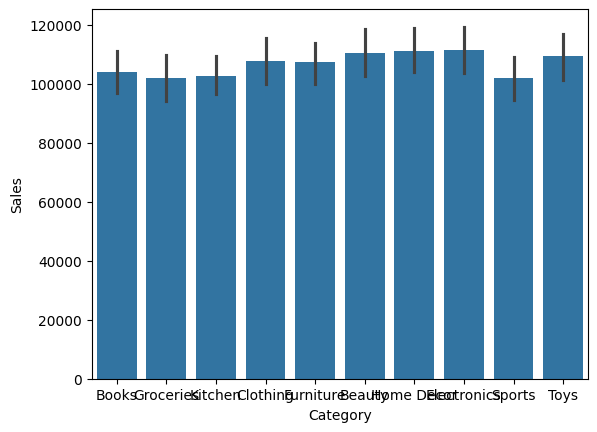

In [47]:
# Category vs Sales

sns.barplot(x="Category", y="Sales", data=df)
plt.show()

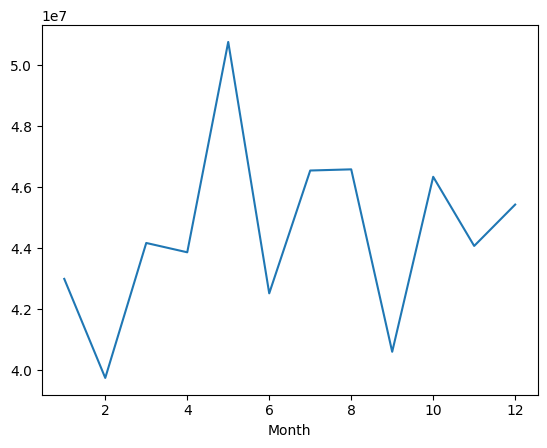

In [48]:
# Monthly sales trend

df.groupby("Month")["Sales"].sum().plot()
plt.show()

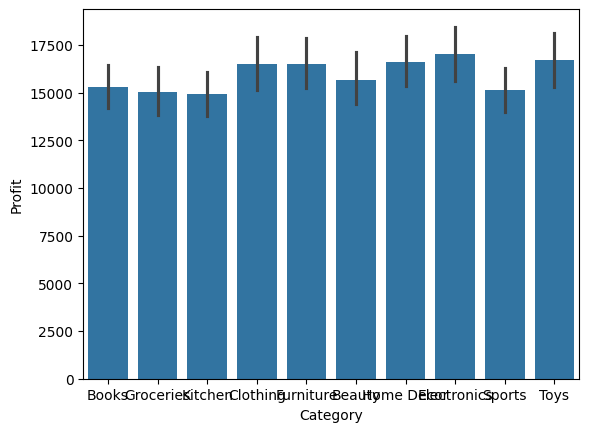

In [49]:
# Profit by Category

sns.barplot(x="Category", y="Profit", data=df)
plt.show()

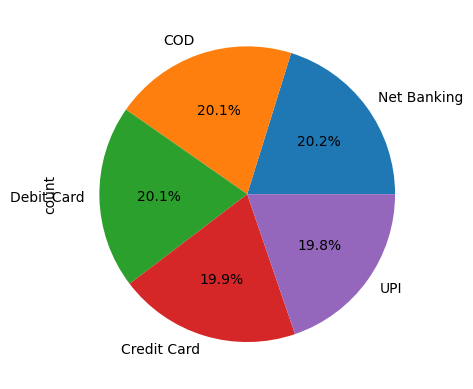

In [50]:
# Payment mode pie chart

df["Payment Mode"].value_counts().plot.pie(autopct="%1.1f%%")
plt.show()